# IR-CFA-CCNet core-val fixed v4

Ключевое исправление: validation split IR-CFA теперь строится из core ensemble cache ids, а train исключает эти ids.
Сначала запусти setup/mount/unzip, затем cells 1–9.


In [ ]:
# Optional Colab setup. Раскомментируй unzip, если папки train_images/test_images ещё не распакованы.
from google.colab import drive
drive.mount('/content/drive')

# !unzip -oq /content/drive/MyDrive/YAN/train_images.zip -d /content/
# !unzip -oq /content/drive/MyDrive/YAN/test_images.zip -d /content/
# import os
# print(len(os.listdir('/content/train_images')), len(os.listdir('/content/test_images')))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -oq /content/drive/MyDrive/YAN/train_images.zip -d /content/
!unzip -oq /content/drive/MyDrive/YAN/test_images.zip -d /content/
import os
print(len(os.listdir('/content/train_images')), len(os.listdir('/content/test_images')))


50000 10000


In [ ]:
# ============================================================
# CELL 1: imports + configs
# ============================================================

import os
import gc
import math
import time
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from tqdm.auto import tqdm
from IPython.display import clear_output

warnings.filterwarnings("ignore")


# ----------------------------
# Required Colab paths
# ----------------------------
TRAIN_IMG_DIR = "/content/train_images"
TEST_IMG_DIR  = "/content/test_images"
LABELS_CSV    = "/content/drive/MyDrive/YAN/train_solution.csv"
SAVE_DIR      = "/content/drive/MyDrive/YAN"
CACHE_DIR     = os.path.join(SAVE_DIR, "ensemble_prob_cache")

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)


class CFG:
    # Reproducibility
    seed = 42

    # Data
    image_size = 256
    positive_label = 1

    # IMPORTANT: anti-leakage split source.
    # IR-CFA validation must equal the validation ids used by the core ensemble.
    use_external_core_val_split = True
    core_val_cache_path = os.path.join(CACHE_DIR, "default_val_efficientnet_ema_probs_logits.csv")
    external_val_expected_n = 10000
    allow_random_split_fallback = False  # keep False; random fallback can reintroduce leakage
    val_size = 0.20                      # only used if external split is deliberately disabled
    split_seed = 42

    # Output cache paths for honest IR-CFA predictions.
    ir_cfa_val_cache_path = os.path.join(CACHE_DIR, "default_val_ir_cfa_ccnet_probs_logits.csv")
    ir_cfa_test_cache_path = os.path.join(CACHE_DIR, "default_test_ir_cfa_ccnet_probs_logits.csv")

    # Dataloader
    batch_size = 32
    num_workers = 2
    pin_memory = True
    persistent_workers = False

    # Model
    model_name = "ir_cfa_ccnet_coreval_v4"
    cfa_width = 16
    stem_dim = 48
    dims = (48, 96, 160, 256)
    depths = (2, 3, 5, 2)
    cov_dim = 32
    dropout = 0.25          # mild increase vs old run; helps when valid loss rises after mid-training
    drop_path_rate = 0.00

    # Numerical stability
    # Keep input in [0,1]. ImageNet normalization is intentionally NOT used.
    # ImpulseGate thresholds, high-pass residuals and pseudo-CFA masks assume physical RGB scale.
    use_imagenet_normalization = False
    detach_cov_from_backbone = True
    gem_trainable_p = False
    feature_clip = 10.0
    cov_clip = 5.0
    logit_tanh_scale = 12.0
    adam_eps = 1e-6
    grad_value_clip = 1.0
    max_bad_grad_batches_per_epoch = 200

    # CFA self-supervised warmup
    # This is not external pretraining. It uses only train-real images after core-val exclusion.
    pretrain_cfa_epochs = 3
    pretrain_cfa_lr = 1e-3
    pretrain_cfa_weight_decay = 1e-4
    cfa_pretrain_amp = True
    freeze_cfa_after_pretrain = True
    auto_unfreeze_cfa_if_diag_weak = False
    cfa_diag_min_abs_rel_delta = 0.010

    # Main training
    epochs = 35
    lr = 3e-4
    min_lr = 1e-6
    weight_decay = 4e-2      # mild increase for calibration/generalization
    warmup_epochs = 3
    grad_clip_norm = 1.0

    # Loss
    use_auto_pos_weight = True
    manual_pos_weight = 4.88
    soft_f1_weight = 0.0     # keep BCE stable first; tune threshold for F1 separately
    soft_f1_start_epoch = 12

    # EMA
    use_ema = True
    ema_decay = 0.999

    # AMP
    # Stage B default is fp32. This is safer for covariance/statistical forensic heads on T4.
    amp = False

    # Thresholds
    fixed_threshold = 0.50
    threshold_min = 0.05
    threshold_max = 0.95
    threshold_steps = 181

    # TTA
    tta_modes = ("orig", "hflip")

    # Saving / output
    save_every_epoch = True
    progress_bar_leave = False
    dashboard_clear_output = True
    save_dashboard_png = True

    # Early stopping.
    # We still save min-loss checkpoint separately; training monitor is best F1 because competition metric is F1.
    early_stopping_patience = 8
    early_stopping_min_delta = 1e-5


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(CFG.amp and torch.cuda.is_available())
CFA_PRETRAIN_AMP_ENABLED = bool(CFG.cfa_pretrain_amp and torch.cuda.is_available())


BEST_F1_CKPT_PATH   = os.path.join(SAVE_DIR, f"{CFG.model_name}_best_f1.pt")
BEST_LOSS_CKPT_PATH = os.path.join(SAVE_DIR, f"{CFG.model_name}_min_valid_loss.pt")
BEST_CKPT_PATH      = BEST_F1_CKPT_PATH  # backward-compatible alias
LAST_CKPT_PATH      = os.path.join(SAVE_DIR, f"{CFG.model_name}_last.pt")
HISTORY_CSV         = os.path.join(SAVE_DIR, f"{CFG.model_name}_history.csv")


# Detailed prediction files, in addition to cache-compatible files.
VAL_PRED_CSV_BEST_F1   = os.path.join(SAVE_DIR, f"{CFG.model_name}_val_predictions_best_f1.csv")
TEST_PRED_CSV_BEST_F1  = os.path.join(SAVE_DIR, f"{CFG.model_name}_test_predictions_best_f1.csv")
VAL_PRED_CSV_MIN_LOSS  = os.path.join(SAVE_DIR, f"{CFG.model_name}_val_predictions_min_valid_loss.csv")
TEST_PRED_CSV_MIN_LOSS = os.path.join(SAVE_DIR, f"{CFG.model_name}_test_predictions_min_valid_loss.csv")


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


def cfg_to_dict():
    out = {}
    for k, v in CFG.__dict__.items():
        if not k.startswith("__") and not callable(v):
            if isinstance(v, tuple):
                v = list(v)
            out[k] = v
    return out


seed_everything(CFG.seed)

print("DEVICE:", DEVICE)
print("Stage B AMP:", AMP_ENABLED)
print("CFA pretrain AMP:", CFA_PRETRAIN_AMP_ENABLED)
print("SAVE_DIR:", SAVE_DIR)
print("CACHE_DIR:", CACHE_DIR)
print("Core-val cache:", CFG.core_val_cache_path)
print("IR-CFA val cache:", CFG.ir_cfa_val_cache_path)
print("Normalization: [0,1] RGB, no ImageNet normalization for CFA/forensic residuals")


DEVICE: cuda
Stage B AMP: False
CFA pretrain AMP: True
SAVE_DIR: /content/drive/MyDrive/YAN
CACHE_DIR: /content/drive/MyDrive/YAN/ensemble_prob_cache
Core-val cache: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_efficientnet_ema_probs_logits.csv
IR-CFA val cache: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_ir_cfa_ccnet_probs_logits.csv
Normalization: [0,1] RGB, no ImageNet normalization for CFA/forensic residuals


In [ ]:
# CELL 2: model architecture
# ============================================================


def count_parameters(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def set_requires_grad(module, flag: bool):
    for p in module.parameters():
        p.requires_grad = bool(flag)


def _gn_groups(channels: int):
    for g in [32, 16, 8, 4, 2, 1]:
        if channels % g == 0:
            return g
    return 1


def safe_nan_to_num(x, clip=None):
    x = torch.nan_to_num(x, nan=0.0, posinf=1e4, neginf=-1e4)
    if clip is not None:
        x = x.clamp(-float(clip), float(clip))
    return x


def drop_path(x, drop_prob: float = 0.0, training: bool = False):
    if drop_prob == 0.0 or not training:
        return x
    keep_prob = 1.0 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()
    return x.div(keep_prob) * random_tensor


class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = float(drop_prob)

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)


class ConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=None, act=True):
        super().__init__()
        if padding is None:
            padding = kernel_size // 2
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride, padding=padding, bias=False)
        self.norm = nn.GroupNorm(_gn_groups(out_ch), out_ch, eps=1e-5)
        self.act = nn.SiLU(inplace=True) if act else nn.Identity()

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))


class DSConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=None, act=True):
        super().__init__()
        if padding is None:
            padding = kernel_size // 2
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size, stride=stride, padding=padding, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.norm = nn.GroupNorm(_gn_groups(out_ch), out_ch, eps=1e-5)
        self.act = nn.SiLU(inplace=True) if act else nn.Identity()

    def forward(self, x):
        return self.act(self.norm(self.pw(self.dw(x))))


class ImpulseGate(nn.Module):
    """
    Salt/pepper/noise-overlay robust gate.
    Expects x in [0,1]. Returns cleaned image and unreliable-pixel mask.
    """
    def __init__(self, thr_low=0.03, thr_high=0.97, diff_thr=0.15):
        super().__init__()
        self.thr_low = float(thr_low)
        self.thr_high = float(thr_high)
        self.diff_thr = float(diff_thr)

    @staticmethod
    def median_pool3x3(x):
        b, c, h, w = x.shape
        xp = F.pad(x, (1, 1, 1, 1), mode="reflect")
        patches = F.unfold(xp, kernel_size=3, padding=0)
        patches = patches.view(b, c, 9, h, w)
        return patches.median(dim=2).values

    def forward(self, x):
        x = x.float().clamp(0.0, 1.0)
        med = self.median_pool3x3(x)
        extreme = (x < self.thr_low) | (x > self.thr_high)
        dev = (x - med).abs() > self.diff_thr
        mask_c = (extreme & dev).float()
        mask = mask_c.amax(dim=1, keepdim=True)
        x_clean = torch.where(mask_c.bool(), med, x)
        return x_clean, mask


class TinyCFAPredictor(nn.Module):
    def __init__(self, in_ch=7, width=16):
        super().__init__()
        w = int(width)
        self.stem = nn.Sequential(ConvGNAct(in_ch, w, 3, 1), DSConvGNAct(w, w, 3, 1))
        self.down1 = nn.Sequential(ConvGNAct(w, w * 2, 3, 2), DSConvGNAct(w * 2, w * 2, 3, 1))
        self.down2 = nn.Sequential(ConvGNAct(w * 2, w * 3, 3, 2), DSConvGNAct(w * 3, w * 3, 3, 1))
        self.down3 = nn.Sequential(ConvGNAct(w * 3, w * 4, 3, 2), DSConvGNAct(w * 4, w * 4, 3, 1))
        self.up3 = nn.Sequential(ConvGNAct(w * 4 + w * 3, w * 3, 3, 1), DSConvGNAct(w * 3, w * 3, 3, 1))
        self.up2 = nn.Sequential(ConvGNAct(w * 3 + w * 2, w * 2, 3, 1), DSConvGNAct(w * 2, w * 2, 3, 1))
        self.up1 = nn.Sequential(ConvGNAct(w * 2 + w, w, 3, 1), DSConvGNAct(w, w, 3, 1))
        self.out = nn.Conv2d(w, 3, kernel_size=1)

    def forward(self, x):
        s1 = self.stem(x)
        s2 = self.down1(s1)
        s3 = self.down2(s2)
        s4 = self.down3(s3)
        u3 = F.interpolate(s4, size=s3.shape[-2:], mode="bilinear", align_corners=False)
        u3 = self.up3(torch.cat([u3, s3], dim=1))
        u2 = F.interpolate(u3, size=s2.shape[-2:], mode="bilinear", align_corners=False)
        u2 = self.up2(torch.cat([u2, s2], dim=1))
        u1 = F.interpolate(u2, size=s1.shape[-2:], mode="bilinear", align_corners=False)
        u1 = self.up1(torch.cat([u1, s1], dim=1))
        return self.out(u1)


class ForensicBlock(nn.Module):
    def __init__(self, dim, mlp_ratio=2.0, drop_path_rate=0.0, layer_scale_init=1e-5):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.dw = nn.Conv2d(dim, dim, kernel_size=5, padding=2, groups=dim, bias=True)
        self.norm = nn.GroupNorm(_gn_groups(dim), dim, eps=1e-5)
        self.pw1 = nn.Conv2d(dim, hidden, kernel_size=1)
        self.act = nn.GELU()
        self.pw2 = nn.Conv2d(hidden, dim, kernel_size=1)
        self.gamma = nn.Parameter(layer_scale_init * torch.ones(dim))
        self.drop_path = DropPath(drop_path_rate)

    def forward(self, x):
        y = self.dw(x)
        y = self.norm(y)
        y = self.pw1(y)
        y = self.act(y)
        y = self.pw2(y)
        y = y * self.gamma.view(1, -1, 1, 1)
        y = safe_nan_to_num(y, clip=CFG.feature_clip)
        return x + self.drop_path(y)


class SignedGeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6, trainable=False):
        super().__init__()
        if trainable:
            self.p = nn.Parameter(torch.ones(1) * float(p))
        else:
            self.register_buffer("p", torch.ones(1) * float(p))
        self.eps = float(eps)

    def _gem(self, x):
        p = self.p.float().clamp(1.0, 4.0)
        x = x.float().clamp(min=self.eps, max=CFG.feature_clip).pow(p)
        x = F.adaptive_avg_pool2d(x, 1).pow(1.0 / p)
        return x.flatten(1)

    def forward(self, x):
        with autocast(enabled=False):
            x = safe_nan_to_num(x.float(), clip=CFG.feature_clip)
            pos = self._gem(F.relu(x))
            neg = self._gem(F.relu(-x))
            out = pos - neg
            return safe_nan_to_num(out, clip=CFG.feature_clip)


class IRCFACCNet(nn.Module):
    """
    IR-CFA-CCNet fixed v3:
    - impulse robust input gate
    - 4-phase pseudo-Bayer CFA reconstruction residuals
    - phase-aware pixel-unshuffle stem
    - compact ConvNeXt-like forensic trunk
    - fp32 stable GeM + covariance statistics head
    """
    def __init__(
        self,
        image_size=256,
        cfa_width=16,
        stem_dim=48,
        dims=(48, 96, 160, 256),
        depths=(2, 3, 5, 2),
        cov_dim=32,
        dropout=0.20,
        drop_path_rate=0.00,
        detach_cov_from_backbone=True,
        gem_trainable_p=False,
        feature_clip=10.0,
        cov_clip=5.0,
        logit_tanh_scale=12.0,
    ):
        super().__init__()
        self.arch_config = dict(
            image_size=image_size,
            cfa_width=cfa_width,
            stem_dim=stem_dim,
            dims=tuple(dims),
            depths=tuple(depths),
            cov_dim=cov_dim,
            dropout=dropout,
            drop_path_rate=drop_path_rate,
            detach_cov_from_backbone=detach_cov_from_backbone,
            gem_trainable_p=gem_trainable_p,
            feature_clip=feature_clip,
            cov_clip=cov_clip,
            logit_tanh_scale=logit_tanh_scale,
        )
        self.detach_cov_from_backbone = bool(detach_cov_from_backbone)
        self.feature_clip = float(feature_clip)
        self.cov_clip = float(cov_clip)
        self.logit_tanh_scale = float(logit_tanh_scale)

        self.gate = ImpulseGate()
        self.cfa_predictor = TinyCFAPredictor(in_ch=7, width=cfa_width)

        stem_in_ch = 31  # hp3 + opponent3 + cfa_err24 + impulse_mask1
        self.stem = nn.Sequential(
            ConvGNAct(stem_in_ch, stem_dim, kernel_size=3, stride=2),
            DSConvGNAct(stem_dim, stem_dim, kernel_size=3, stride=1),
        )
        self.phase_proj = nn.Sequential(
            ConvGNAct(96, stem_dim, kernel_size=1, stride=1, padding=0),
            DSConvGNAct(stem_dim, stem_dim, kernel_size=3, stride=1),
        )

        assert dims[0] == stem_dim
        total_blocks = sum(depths)
        dpr = np.linspace(0, drop_path_rate, total_blocks).tolist() if total_blocks > 0 else []
        ptr = 0

        self.stage1 = nn.Sequential(*[ForensicBlock(dims[0], drop_path_rate=dpr[ptr + i]) for i in range(depths[0])])
        ptr += depths[0]
        self.down12 = ConvGNAct(dims[0], dims[1], kernel_size=3, stride=2)

        self.stage2 = nn.Sequential(*[ForensicBlock(dims[1], drop_path_rate=dpr[ptr + i]) for i in range(depths[1])])
        ptr += depths[1]
        self.down23 = ConvGNAct(dims[1], dims[2], kernel_size=3, stride=2)

        self.stage3 = nn.Sequential(*[ForensicBlock(dims[2], drop_path_rate=dpr[ptr + i]) for i in range(depths[2])])
        ptr += depths[2]
        self.down34 = ConvGNAct(dims[2], dims[3], kernel_size=3, stride=2)

        self.stage4 = nn.Sequential(*[ForensicBlock(dims[3], drop_path_rate=dpr[ptr + i]) for i in range(depths[3])])

        self.gem = SignedGeM(p=3.0, trainable=gem_trainable_p)
        self.cov_proj = nn.Sequential(
            nn.Conv2d(dims[-1], cov_dim, kernel_size=1, bias=False),
            nn.GroupNorm(_gn_groups(cov_dim), cov_dim, eps=1e-5),
            nn.SiLU(inplace=True),
        )

        cov_vec_dim = cov_dim * (cov_dim + 1) // 2
        cfa_stats_dim = 36
        head_in = dims[-1] + cov_vec_dim + cfa_stats_dim
        self.head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.LayerNorm(256, eps=1e-5),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    @staticmethod
    def highpass(x):
        xp = F.pad(x, (1, 1, 1, 1), mode="reflect")
        blur = F.avg_pool2d(xp, kernel_size=3, stride=1, padding=0)
        return x - blur

    @staticmethod
    def opponent_hp(hp):
        r = hp[:, 0:1]
        g = hp[:, 1:2]
        b = hp[:, 2:3]
        return torch.cat([r - g, b - g, r + b - 2.0 * g], dim=1)

    @staticmethod
    def _make_bayer_masks(h, w, device, dtype):
        yy = torch.arange(h, device=device).view(h, 1)
        xx = torch.arange(w, device=device).view(1, w)
        patterns = [
            {(0, 0): "R", (0, 1): "G", (1, 0): "G", (1, 1): "B"},
            {(0, 0): "B", (0, 1): "G", (1, 0): "G", (1, 1): "R"},
            {(0, 0): "G", (0, 1): "R", (1, 0): "B", (1, 1): "G"},
            {(0, 0): "G", (0, 1): "B", (1, 0): "R", (1, 1): "G"},
        ]
        ch = {"R": 0, "G": 1, "B": 2}
        masks = []
        for pat in patterns:
            m = torch.zeros(3, h, w, device=device, dtype=dtype)
            for (ry, rx), color in pat.items():
                pos = ((yy % 2) == ry) & ((xx % 2) == rx)
                m[ch[color]][pos] = 1.0
            masks.append(m)
        return torch.stack(masks, dim=0).unsqueeze(0)

    def _compute_cfa_error(self, hp, impulse_mask):
        b, c, h, w = hp.shape
        hp = safe_nan_to_num(hp.float(), clip=1.0)
        impulse_mask = impulse_mask.float().clamp(0.0, 1.0)
        masks = self._make_bayer_masks(h, w, hp.device, hp.dtype).expand(b, -1, -1, -1, -1)
        obs = hp.unsqueeze(1) * masks
        imp = impulse_mask.unsqueeze(1).expand(b, 4, 1, h, w)
        cfa_input = torch.cat([obs, masks, imp], dim=2).reshape(b * 4, 7, h, w)
        pred = self.cfa_predictor(cfa_input).reshape(b, 4, 3, h, w)
        pred = safe_nan_to_num(pred.float(), clip=2.0)
        missing = 1.0 - masks
        valid = missing * (1.0 - imp)
        err = (pred - hp.unsqueeze(1)) * valid
        err = safe_nan_to_num(err, clip=2.0)
        return err, valid, pred

    def _cfa_features_and_stats(self, hp, impulse_mask):
        err, valid, pred = self._compute_cfa_error(hp, impulse_mask)
        b, _, _, h, w = err.shape
        signed = err.reshape(b, 12, h, w)
        absolute = err.abs().reshape(b, 12, h, w)
        err_stack = torch.cat([signed, absolute], dim=1)
        err_stack = safe_nan_to_num(err_stack, clip=2.0)

        den = valid.sum(dim=(-1, -2)).clamp_min(1.0)
        abs_err = err.abs()
        abs_mean = abs_err.sum(dim=(-1, -2)) / den
        signed_mean = err.sum(dim=(-1, -2)) / den
        centered = (abs_err - abs_mean[..., None, None]) * valid
        abs_var = (centered ** 2).sum(dim=(-1, -2)) / den
        abs_std = torch.sqrt(abs_var.clamp_min(0.0) + 1e-6)
        stats = torch.cat([abs_mean.flatten(1), abs_std.flatten(1), signed_mean.flatten(1)], dim=1)
        stats = safe_nan_to_num(stats.float(), clip=1.0)
        return err_stack, stats

    def _cov_pool(self, f):
        with autocast(enabled=False):
            if self.detach_cov_from_backbone:
                f = f.detach()
            f = safe_nan_to_num(f.float(), clip=self.feature_clip)
            r = self.cov_proj(f)
            r = safe_nan_to_num(r.float(), clip=self.feature_clip)
            b, c, h, w = r.shape
            r = r.flatten(2)
            r = r - r.mean(dim=2, keepdim=True)
            r_std = r.std(dim=2, keepdim=True).clamp_min(1e-3)
            r = (r / r_std).clamp(-self.feature_clip, self.feature_clip)
            denom = max(r.shape[-1] - 1, 1)
            cov = torch.bmm(r, r.transpose(1, 2)) / float(denom)
            cov = torch.asinh(cov).clamp(-self.cov_clip, self.cov_clip)
            idx = torch.triu_indices(c, c, device=f.device)
            cov_vec = cov[:, idx[0], idx[1]]
            return safe_nan_to_num(cov_vec, clip=self.cov_clip)

    def forward_features(self, x):
        x = x.float().clamp(0.0, 1.0)
        x_clean, impulse_mask = self.gate(x)
        hp = self.highpass(x_clean)
        hp = safe_nan_to_num(hp, clip=1.0)
        opp = self.opponent_hp(hp)
        opp = safe_nan_to_num(opp, clip=2.0)
        err_stack, cfa_stats = self._cfa_features_and_stats(hp, impulse_mask)

        z = torch.cat([hp, opp, err_stack, impulse_mask.float()], dim=1)
        z = safe_nan_to_num(z, clip=2.0)

        phase = F.pixel_unshuffle(err_stack, downscale_factor=2)
        h = self.stem(z) + self.phase_proj(phase)
        h = safe_nan_to_num(h, clip=self.feature_clip)
        h = self.stage1(h)
        h = self.down12(h)
        h = self.stage2(h)
        h = self.down23(h)
        h = self.stage3(h)
        h = self.down34(h)
        f = self.stage4(h)
        f = safe_nan_to_num(f, clip=self.feature_clip)

        gem = self.gem(f)
        cov = self._cov_pool(f)
        feat = torch.cat([gem.float(), cov.float(), cfa_stats.float()], dim=1)
        feat = safe_nan_to_num(feat, clip=max(self.feature_clip, self.cov_clip))
        return feat

    def forward(self, x):
        feat = self.forward_features(x)
        with autocast(enabled=False):
            raw = self.head(feat.float()).squeeze(1)
            raw = safe_nan_to_num(raw, clip=50.0)
            scale = self.logit_tanh_scale
            logit = scale * torch.tanh(raw / scale)
            logit = safe_nan_to_num(logit, clip=scale)
        return {"logit": logit}

    def cfa_reconstruction_loss(self, x):
        x = x.float().clamp(0.0, 1.0)
        x_clean, impulse_mask = self.gate(x)
        hp = safe_nan_to_num(self.highpass(x_clean), clip=1.0)
        err, valid, pred = self._compute_cfa_error(hp, impulse_mask)
        loss = F.smooth_l1_loss(err, torch.zeros_like(err), beta=0.02, reduction="sum")
        loss = loss / valid.sum().clamp_min(1.0)
        return safe_nan_to_num(loss.float(), clip=10.0)

    @torch.no_grad()
    def cfa_reconstruction_error_per_image(self, x):
        x = x.float().clamp(0.0, 1.0)
        x_clean, impulse_mask = self.gate(x)
        hp = safe_nan_to_num(self.highpass(x_clean), clip=1.0)
        err, valid, pred = self._compute_cfa_error(hp, impulse_mask)
        num = err.abs().sum(dim=(1, 2, 3, 4))
        den = valid.sum(dim=(1, 2, 3, 4)).clamp_min(1.0)
        return num / den


def set_cfa_trainable(model, trainable=True):
    set_requires_grad(model.cfa_predictor, bool(trainable))


_tmp_model = IRCFACCNet(
    image_size=CFG.image_size,
    cfa_width=CFG.cfa_width,
    stem_dim=CFG.stem_dim,
    dims=CFG.dims,
    depths=CFG.depths,
    cov_dim=CFG.cov_dim,
    dropout=CFG.dropout,
    drop_path_rate=CFG.drop_path_rate,
    detach_cov_from_backbone=CFG.detach_cov_from_backbone,
    gem_trainable_p=CFG.gem_trainable_p,
    feature_clip=CFG.feature_clip,
    cov_clip=CFG.cov_clip,
    logit_tanh_scale=CFG.logit_tanh_scale,
)
print("IR-CFA-CCNet total params:", count_parameters(_tmp_model, trainable_only=False))
print("IR-CFA-CCNet trainable params:", count_parameters(_tmp_model, trainable_only=True))
del _tmp_model
gc.collect()


# ============================================================

# ============================================================


IR-CFA-CCNet total params: 2152084
IR-CFA-CCNet trainable params: 2152084


30

In [ ]:
# ============================================================
# CELL 3: data pipeline
# ============================================================

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


def has_image_ext(x):
    return Path(str(x)).suffix.lower() in IMG_EXTENSIONS


def canonical_id(x):
    """
    Robust id key used only for matching splits/caches.
    Examples:
        123.jpg -> 123
        /path/123.jpg -> 123
        "000123" -> 123, matching cache files that store ids as ints.
    """
    s = str(x).strip()
    s = os.path.basename(s)
    if s.lower() in {"nan", "none", ""}:
        return s

    # Strip known image suffixes, including repeated suffixes.
    while Path(s).suffix.lower() in IMG_EXTENSIONS:
        s = Path(s).stem

    if s.isdigit():
        try:
            s = str(int(s))
        except Exception:
            pass
    return s


def read_labels_csv(csv_path):
    """
    Flexible reader for train_solution.csv.
    Supports both headered csv and old header=None style with two columns.
    Output columns: id, target.
    """
    df_raw = pd.read_csv(csv_path)
    cols = list(df_raw.columns)
    lower_map = {str(c).lower(): c for c in cols}

    id_candidates = ["id", "image_id", "image", "filename", "file_name", "file", "filepath", "path", "name"]
    target_candidates = ["target_feature", "target", "label", "class", "is_fake", "fake", "y"]

    id_col = None
    for c in id_candidates:
        if c in lower_map:
            id_col = lower_map[c]
            break

    target_col = None
    for c in target_candidates:
        if c in lower_map:
            target_col = lower_map[c]
            break

    # Fallback for headerless train_solution.csv.
    if id_col is None or target_col is None:
        df_no_header = pd.read_csv(csv_path, header=None)
        if df_no_header.shape[1] < 2:
            raise ValueError(f"Could not infer id/target columns from {csv_path}. Columns: {cols}")
        df = df_no_header.iloc[:, :2].copy()
        df.columns = ["id", "target"]
        original_id_col, original_target_col = 0, 1
    else:
        df = df_raw[[id_col, target_col]].copy()
        df.columns = ["id", "target"]
        original_id_col, original_target_col = id_col, target_col

    df["id"] = df["id"].astype(str).str.strip()

    if df["target"].dtype == object:
        s = df["target"].astype(str).str.lower().str.strip()
        mapping = {
            "real": 0, "negative": 0, "neg": 0, "0": 0,
            "fake": 1, "ai": 1, "generated": 1, "synthetic": 1,
            "positive": 1, "pos": 1, "1": 1,
        }
        df["target"] = s.map(mapping)
        if df["target"].isna().any():
            bad = s[df["target"].isna()].unique()[:10]
            raise ValueError(f"Unmapped target values: {bad}")
        df["target"] = df["target"].astype(int)
    else:
        df["target"] = df["target"].astype(int)

    return df, original_id_col, original_target_col


def build_image_index(img_dir):
    img_dir = Path(img_dir)
    mapping = {}
    for p in img_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS:
            mapping[p.name] = str(p)
            mapping[p.stem] = str(p)
            mapping[canonical_id(p.name)] = str(p)
            try:
                mapping[str(p.relative_to(img_dir))] = str(p)
            except Exception:
                pass
    return mapping


def resolve_image_path(image_id, img_dir, image_index=None):
    sid = str(image_id).strip()
    img_dir = Path(img_dir)

    p = Path(sid)
    if p.is_absolute() and p.exists():
        return str(p)

    cand = img_dir / sid
    if cand.exists():
        return str(cand)

    if image_index is not None:
        if sid in image_index:
            return image_index[sid]
        stem = Path(sid).stem
        if stem in image_index:
            return image_index[stem]
        key = canonical_id(sid)
        if key in image_index:
            return image_index[key]

    for ext in IMG_EXTENSIONS:
        cand = img_dir / f"{sid}{ext}"
        if cand.exists():
            return str(cand)
        cand = img_dir / f"{canonical_id(sid)}{ext}"
        if cand.exists():
            return str(cand)

    raise FileNotFoundError(f"Could not resolve image path for id={sid} in {img_dir}")


def ids_mostly_have_ext(ids, n_check=1000):
    ids = list(ids)[:n_check]
    if len(ids) == 0:
        return False
    return np.mean([has_image_ext(x) for x in ids]) > 0.5


def stratified_split_df(df, val_size=0.2, seed=42):
    rng = np.random.RandomState(seed)
    train_idx = []
    val_idx = []
    for cls in sorted(df["target"].unique()):
        idx = df.index[df["target"] == cls].to_numpy()
        rng.shuffle(idx)
        n_val = int(round(len(idx) * val_size))
        n_val = max(1, n_val)
        val_idx.extend(idx[:n_val].tolist())
        train_idx.extend(idx[n_val:].tolist())
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return df.loc[train_idx].reset_index(drop=True), df.loc[val_idx].reset_index(drop=True)


def load_external_val_ids_from_cache(cache_path, expected_n=None, id_col=None):
    if not os.path.exists(cache_path):
        raise FileNotFoundError(
            f"External core-val cache not found: {cache_path}. "
            "This file is required to avoid leakage."
        )

    df = pd.read_csv(cache_path)
    if id_col is None:
        if "id" in df.columns:
            id_col = "id"
        elif "Id" in df.columns:
            id_col = "Id"
        else:
            id_col = df.columns[0]

    ids_ordered = []
    seen = set()
    for x in df[id_col].values:
        key = canonical_id(x)
        if key not in seen:
            ids_ordered.append(key)
            seen.add(key)

    if expected_n is not None:
        assert len(ids_ordered) == int(expected_n), (
            f"Expected {expected_n} unique core_val ids from {cache_path}, got {len(ids_ordered)}. "
            "Check cache file and id column."
        )

    print(f"Loaded external core_val_ids from: {cache_path}")
    print(f"  unique ids: {len(ids_ordered)}")
    return ids_ordered


def build_train_val_from_external_val_ids(labels_df, external_val_ids, expected_n=None):
    """
    Anti-leakage split:
      IR-CFA val = external core_val_ids
      IR-CFA train = all training ids minus external core_val_ids
    """
    df = labels_df.copy().reset_index(drop=True)
    df["_key"] = df["id"].map(canonical_id)

    if df["_key"].duplicated().any():
        dup = df.loc[df["_key"].duplicated(), "id"].head(10).tolist()
        raise ValueError(f"Duplicate canonical ids in labels_df. Examples: {dup}")

    core_val_order = [canonical_id(x) for x in external_val_ids]
    core_val_set = set(core_val_order)
    all_train_set = set(df["_key"].values)

    missing = sorted(core_val_set - all_train_set)
    if len(missing) > 0:
        raise ValueError(
            f"{len(missing)} core_val ids are missing from train_solution.csv. "
            f"Examples: {missing[:10]}"
        )

    order_map = {k: i for i, k in enumerate(core_val_order)}
    val_mask = df["_key"].isin(core_val_set)

    val_df = df.loc[val_mask].copy()
    val_df["_order"] = val_df["_key"].map(order_map)
    val_df = val_df.sort_values("_order").reset_index(drop=True)

    train_df = df.loc[~val_mask].copy().reset_index(drop=True)

    ir_train_keys = set(train_df["_key"].values)
    ir_val_keys = set(val_df["_key"].values)

    inter_train = core_val_set & ir_train_keys
    inter_val = core_val_set & ir_val_keys

    print("Anti-leakage split check")
    print(f"  core_val total unique: {len(core_val_set)}")
    print(f"  IR-CFA train size:     {len(train_df)}")
    print(f"  IR-CFA val size:       {len(val_df)}")
    print(f"  core_val ∩ ir_train:   {len(inter_train)}")
    print(f"  core_val ∩ ir_val:     {len(inter_val)}")

    assert len(inter_train) == 0, "LEAKAGE: some core_val ids are inside IR-CFA train_df."
    assert inter_val == core_val_set, "IR-CFA val ids do not exactly match core_val ids."
    if expected_n is not None:
        assert len(inter_val) == int(expected_n), (
            f"Expected core_val ∩ ir_val == {expected_n}, got {len(inter_val)}."
        )

    # Drop helper columns before Dataset.
    train_df = train_df.drop(columns=["_key"], errors="ignore")
    val_df = val_df.drop(columns=["_key", "_order"], errors="ignore")

    return train_df, val_df, core_val_order


class ImageBinaryDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, has_labels=True, image_index=None):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = img_dir
        self.transform = transform
        self.has_labels = bool(has_labels)
        self.image_index = image_index

    def __len__(self):
        return len(self.df)

    def _get_path(self, row):
        if "path" in row and isinstance(row["path"], str) and len(row["path"]) > 0:
            return row["path"]
        return resolve_image_path(row["id"], self.img_dir, self.image_index)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = self._get_path(row)
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        out = {"image": img, "id": str(row["id"])}
        if self.has_labels:
            out["target"] = torch.tensor(float(row["target"]), dtype=torch.float32)
        return out


def build_test_dataframe(test_img_dir, train_id_has_ext=False):
    files = []
    for p in Path(test_img_dir).rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS:
            files.append(p)
    files = sorted(files, key=lambda x: canonical_id(x.name))
    ids = [p.name if train_id_has_ext else p.stem for p in files]
    return pd.DataFrame({"id": ids, "path": [str(p) for p in files]})


def seed_worker(worker_id):
    worker_seed = CFG.seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def build_dataloader(dataset, batch_size, shuffle, drop_last=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CFG.num_workers,
        pin_memory=CFG.pin_memory,
        drop_last=drop_last,
        worker_init_fn=seed_worker,
        persistent_workers=CFG.persistent_workers if CFG.num_workers > 0 else False,
    )


def build_full_data(
    train_img_dir=TRAIN_IMG_DIR,
    test_img_dir=TEST_IMG_DIR,
    labels_csv=LABELS_CSV,
    train_transform=None,
    valid_transform=None,
    batch_size=CFG.batch_size,
    val_size=CFG.val_size,
    seed=CFG.split_seed,
    use_external_val_split=CFG.use_external_core_val_split,
    external_val_cache_path=CFG.core_val_cache_path,
    external_val_expected_n=CFG.external_val_expected_n,
):
    labels_df, original_id_col, original_target_col = read_labels_csv(labels_csv)
    train_id_has_ext = ids_mostly_have_ext(labels_df["id"].values)

    print("Building train image index...")
    train_index = build_image_index(train_img_dir)

    print("Resolving train paths...")
    labels_df["path"] = [resolve_image_path(x, train_img_dir, train_index) for x in labels_df["id"].values]

    core_val_ids = None
    split_source = "random_stratified"

    if use_external_val_split:
        if (not os.path.exists(external_val_cache_path)) and CFG.allow_random_split_fallback:
            print("WARNING: external val cache missing; falling back to random stratified split.")
            train_df, val_df = stratified_split_df(labels_df, val_size=val_size, seed=seed)
        else:
            core_val_ids = load_external_val_ids_from_cache(
                external_val_cache_path,
                expected_n=external_val_expected_n,
            )
            train_df, val_df, core_val_ids = build_train_val_from_external_val_ids(
                labels_df,
                core_val_ids,
                expected_n=external_val_expected_n,
            )
            split_source = external_val_cache_path
    else:
        print("WARNING: using random stratified split. This is not safe for core-ensemble blending unless it matches core split.")
        train_df, val_df = stratified_split_df(labels_df, val_size=val_size, seed=seed)

    print("Building test dataframe...")
    test_df = build_test_dataframe(test_img_dir, train_id_has_ext=train_id_has_ext)

    if train_transform is None:
        train_transform = get_train_transform()
    if valid_transform is None:
        valid_transform = get_valid_transform("orig")

    train_ds = ImageBinaryDataset(train_df, train_img_dir, transform=train_transform, has_labels=True, image_index=train_index)
    val_ds = ImageBinaryDataset(val_df, train_img_dir, transform=valid_transform, has_labels=True, image_index=train_index)

    train_loader = build_dataloader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = build_dataloader(val_ds, batch_size=batch_size * 2, shuffle=False, drop_last=False)

    n_pos = int((train_df["target"] == 1).sum())
    n_neg = int((train_df["target"] == 0).sum())
    val_pos = int((val_df["target"] == 1).sum())
    val_neg = int((val_df["target"] == 0).sum())

    print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")
    print(f"Train class counts: neg/real={n_neg}, pos/fake={n_pos}, ratio n_neg/n_pos={n_neg / max(n_pos, 1):.4f}")
    print(f"Val class counts:   neg/real={val_neg}, pos/fake={val_pos}, ratio n_neg/n_pos={val_neg / max(val_pos, 1):.4f}")
    print(f"Original CSV id_col={original_id_col}, target_col={original_target_col}")
    print(f"train_id_has_ext={train_id_has_ext}")
    print(f"split_source={split_source}")

    return {
        "labels_df": labels_df,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "train_index": train_index,
        "train_id_has_ext": train_id_has_ext,
        "original_id_col": original_id_col,
        "original_target_col": original_target_col,
        "n_pos": n_pos,
        "n_neg": n_neg,
        "val_n_pos": val_pos,
        "val_n_neg": val_neg,
        "core_val_ids": core_val_ids,
        "split_source": split_source,
        "external_val_cache_path": external_val_cache_path if use_external_val_split else None,
    }


def assert_no_leakage_against_core_val(train_df, val_df, core_val_ids, expected_n=CFG.external_val_expected_n):
    if core_val_ids is None:
        raise ValueError("core_val_ids is None. Cannot perform anti-leakage assertion.")
    core_set = set(canonical_id(x) for x in core_val_ids)
    train_set = set(canonical_id(x) for x in train_df["id"].values)
    val_set = set(canonical_id(x) for x in val_df["id"].values)
    inter_train = core_set & train_set
    inter_val = core_set & val_set
    print("Final leakage assert")
    print(f"  core_val ∩ ir_train: {len(inter_train)}")
    print(f"  core_val ∩ ir_val:   {len(inter_val)}")
    assert len(inter_train) == 0, "LEAKAGE: core_val ids found in IR-CFA train split."
    assert inter_val == core_set, "IR-CFA val split is not exactly core_val_ids."
    if expected_n is not None:
        assert len(inter_val) == int(expected_n), f"Expected {expected_n}, got {len(inter_val)}."
    return True


def build_cfa_pretrain_loader(train_df, train_img_dir=TRAIN_IMG_DIR, train_index=None, batch_size=None):
    # Real-only and no train augmentations. This keeps the pseudo-CFA task clean and also respects core-val exclusion.
    real_df = train_df[train_df["target"] == 0].reset_index(drop=True)
    ds = ImageBinaryDataset(real_df, train_img_dir, transform=get_valid_transform("orig"), has_labels=True, image_index=train_index)
    return build_dataloader(ds, batch_size=batch_size or CFG.batch_size, shuffle=True, drop_last=True)


def build_test_loader(test_df, transform, batch_size=None):
    if batch_size is None:
        batch_size = CFG.batch_size * 2
    ds = ImageBinaryDataset(test_df, TEST_IMG_DIR, transform=transform, has_labels=False, image_index=None)
    return build_dataloader(ds, batch_size=batch_size, shuffle=False, drop_last=False)


In [ ]:
# CELL 4: transforms / augmentations
# ============================================================

class Compose:
    def __init__(self, transforms):
        self.transforms = list(transforms)

    def __call__(self, img):
        for t in self.transforms:
            img = t(img)
        return img


class ToTensor01:
    def __call__(self, img):
        arr = np.array(img, dtype=np.uint8)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)
        if arr.shape[-1] > 3:
            arr = arr[..., :3]
        return torch.from_numpy(arr).permute(2, 0, 1).float() / 255.0


class Clip01:
    def __call__(self, x):
        return x.clamp(0.0, 1.0)


class RandomHorizontalFlipTensor:
    def __init__(self, p=0.5):
        self.p = float(p)

    def __call__(self, x):
        if random.random() < self.p:
            return torch.flip(x, dims=[2])
        return x


class DeterministicHorizontalFlipTensor:
    def __call__(self, x):
        return torch.flip(x, dims=[2])


class RandomIntegerShiftTensor:
    def __init__(self, max_shift=2, p=0.35):
        self.max_shift = int(max_shift)
        self.p = float(p)

    def __call__(self, x):
        if self.max_shift <= 0 or random.random() >= self.p:
            return x
        _, h, w = x.shape
        dy = random.randint(-self.max_shift, self.max_shift)
        dx = random.randint(-self.max_shift, self.max_shift)
        if dy == 0 and dx == 0:
            return x
        pad = self.max_shift
        xp = F.pad(x.unsqueeze(0), (pad, pad, pad, pad), mode="reflect").squeeze(0)
        y0 = pad + dy
        x0 = pad + dx
        return xp[:, y0:y0 + h, x0:x0 + w]


class RandomBrightnessContrastTensor:
    def __init__(self, brightness=0.04, contrast=0.04, p=0.20):
        self.brightness = float(brightness)
        self.contrast = float(contrast)
        self.p = float(p)

    def __call__(self, x):
        if random.random() >= self.p:
            return x
        b = 1.0 + random.uniform(-self.brightness, self.brightness)
        c = 1.0 + random.uniform(-self.contrast, self.contrast)
        mean = x.mean(dim=(1, 2), keepdim=True)
        return (x - mean) * c + mean * b


class RandomSaltPepperTensor:
    def __init__(self, amount=0.0015, p=0.15):
        self.amount = float(amount)
        self.p = float(p)

    def __call__(self, x):
        if self.amount <= 0 or random.random() >= self.p:
            return x
        c, h, w = x.shape
        mask = torch.rand(1, h, w) < self.amount
        values = (torch.rand(1, h, w) < 0.5).float()
        return torch.where(mask.expand(c, h, w), values.expand(c, h, w), x)


def get_train_transform():
    return Compose([
        ToTensor01(),
        RandomHorizontalFlipTensor(p=0.5),
        RandomIntegerShiftTensor(max_shift=2, p=0.35),
        RandomBrightnessContrastTensor(brightness=0.04, contrast=0.04, p=0.20),
        RandomSaltPepperTensor(amount=0.0015, p=0.15),
        Clip01(),
    ])


def get_valid_transform(tta_mode="orig"):
    transforms = [ToTensor01()]
    if tta_mode == "orig":
        pass
    elif tta_mode == "hflip":
        transforms.append(DeterministicHorizontalFlipTensor())
    else:
        raise ValueError(f"Unknown tta_mode={tta_mode}")
    transforms.append(Clip01())
    return Compose(transforms)


# ============================================================


In [ ]:
# ============================================================

# CELL 5: loss / optimizer / scheduler
# ============================================================

class BCEWithLogitsSoftF1Loss(nn.Module):
    def __init__(self, pos_weight=None, soft_f1_weight=0.0, soft_f1_start_epoch=0, eps=1e-7):
        super().__init__()
        if pos_weight is None:
            self.register_buffer("pos_weight_buf", torch.tensor([1.0], dtype=torch.float32))
            self.has_pos_weight = False
        else:
            self.register_buffer("pos_weight_buf", torch.tensor([float(pos_weight)], dtype=torch.float32))
            self.has_pos_weight = True
        self.soft_f1_weight = float(soft_f1_weight)
        self.soft_f1_start_epoch = int(soft_f1_start_epoch)
        self.eps = float(eps)

    def soft_f1_loss(self, logits, targets):
        logits = safe_nan_to_num(logits.float(), clip=CFG.logit_tanh_scale)
        probs = torch.sigmoid(logits)
        targets = targets.float()
        tp = (probs * targets).sum()
        fp = (probs * (1.0 - targets)).sum()
        fn = ((1.0 - probs) * targets).sum()
        soft_f1 = (2.0 * tp + self.eps) / (2.0 * tp + fp + fn + self.eps)
        return 1.0 - soft_f1

    def forward(self, logits, targets, epoch=0):
        logits = safe_nan_to_num(logits.float(), clip=CFG.logit_tanh_scale)
        targets = targets.float().clamp(0.0, 1.0)
        pos_weight = self.pos_weight_buf.to(logits.device) if self.has_pos_weight else None
        bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight, reduction="mean")
        if self.soft_f1_weight > 0 and epoch >= self.soft_f1_start_epoch:
            return bce + self.soft_f1_weight * self.soft_f1_loss(logits, targets)
        return bce


def create_criterion(train_df):
    if CFG.use_auto_pos_weight:
        n_pos = int((train_df["target"] == 1).sum())
        n_neg = int((train_df["target"] == 0).sum())
        pos_weight = n_neg / max(n_pos, 1)
    else:
        pos_weight = CFG.manual_pos_weight
    print(f"Using pos_weight={pos_weight:.4f}")
    return BCEWithLogitsSoftF1Loss(
        pos_weight=pos_weight,
        soft_f1_weight=CFG.soft_f1_weight,
        soft_f1_start_epoch=CFG.soft_f1_start_epoch,
    )


def create_optimizer(model, lr=CFG.lr, weight_decay=CFG.weight_decay):
    decay = []
    no_decay = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        lname = name.lower()
        if param.ndim <= 1 or name.endswith(".bias") or "norm" in lname or "gamma" in lname or lname.endswith(".p"):
            no_decay.append(param)
        else:
            decay.append(param)
    return torch.optim.AdamW(
        [
            {"params": decay, "weight_decay": weight_decay},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=lr,
        betas=(0.9, 0.999),
        eps=CFG.adam_eps,
    )


def create_scheduler(optimizer, num_training_steps, num_warmup_steps, min_lr_ratio=None):
    if min_lr_ratio is None:
        min_lr_ratio = CFG.min_lr / CFG.lr
    num_training_steps = max(1, int(num_training_steps))
    num_warmup_steps = max(0, int(num_warmup_steps))

    def lr_lambda(step):
        if step < num_warmup_steps:
            return float(step + 1) / float(max(1, num_warmup_steps))
        progress = float(step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        cosine = 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.module = copy.deepcopy(model).eval()
        self.decay = float(decay)
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        esd = self.module.state_dict()
        for k, ema_v in esd.items():
            model_v = msd[k].detach()
            if ema_v.dtype.is_floating_point:
                ema_v.copy_(ema_v * self.decay + model_v * (1.0 - self.decay))
            else:
                ema_v.copy_(model_v)

    def state_dict(self):
        return self.module.state_dict()


# ============================================================


In [ ]:
# ============================================================

# CELL 6: train / eval / fit
# ============================================================


def sigmoid_np(x):
    x = np.clip(np.asarray(x, dtype=np.float64), -50, 50)
    return 1.0 / (1.0 + np.exp(-x))


def f1_score_binary_np(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    denom = 2 * tp + fp + fn
    return 0.0 if denom == 0 else float(2 * tp / denom)


def accuracy_binary_np(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    return float((y_true == y_pred).mean()) if len(y_true) else 0.0


def threshold_grid():
    return np.linspace(CFG.threshold_min, CFG.threshold_max, CFG.threshold_steps)


def find_best_f1_threshold(y_true, probs, thresholds=None):
    if thresholds is None:
        thresholds = threshold_grid()
    best_f1 = -1.0
    best_thr = CFG.fixed_threshold
    for thr in thresholds:
        pred = (probs >= thr).astype(int)
        f1 = f1_score_binary_np(y_true, pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)
    return best_f1, best_thr


def get_logits_from_output(output):
    return output["logit"] if isinstance(output, dict) else output


def get_lr(optimizer):
    return float(optimizer.param_groups[0]["lr"])


def sanitize_gradients(model, grad_value_clip=1.0):
    bad_tensors = 0
    max_abs = 0.0
    for p in model.parameters():
        if p.grad is None:
            continue
        g = p.grad.data
        finite = torch.isfinite(g)
        if not finite.all():
            bad_tensors += 1
            g = torch.nan_to_num(g, nan=0.0, posinf=0.0, neginf=0.0)
            p.grad.data.copy_(g)
        if grad_value_clip is not None and grad_value_clip > 0:
            p.grad.data.clamp_(-float(grad_value_clip), float(grad_value_clip))
        if p.grad.numel() > 0:
            max_abs = max(max_abs, float(p.grad.data.abs().max().detach().cpu()))
    return bad_tensors, max_abs


def safe_optimizer_step(model, optimizer, scaler=None, amp=False):
    bad_tensors, max_abs = sanitize_gradients(model, grad_value_clip=CFG.grad_value_clip)
    try:
        total_norm = torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad and p.grad is not None],
            max_norm=CFG.grad_clip_norm,
            error_if_nonfinite=False,
        )
        total_norm_val = float(total_norm.detach().cpu()) if torch.is_tensor(total_norm) else float(total_norm)
    except Exception:
        total_norm_val = float("nan")

    if not np.isfinite(total_norm_val):
        # Do not crash. Sanitize once more and skip this update to avoid corrupting weights.
        optimizer.zero_grad(set_to_none=True)
        return False, bad_tensors + 1, max_abs, total_norm_val

    if amp and scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()
    return True, bad_tensors, max_abs, total_norm_val


def train_one_epoch(model, loader, criterion, optimizer, scheduler=None, scaler=None, ema=None, device=DEVICE, epoch=0, amp=AMP_ENABLED):
    model.train()
    if scaler is None:
        scaler = GradScaler(enabled=amp)

    total_loss = 0.0
    total_n = 0
    all_logits = []
    all_targets = []
    skipped = 0
    bad_grad_batches = 0

    pbar = tqdm(loader, total=len(loader), desc=f"train {epoch:03d}", leave=CFG.progress_bar_leave)
    for step, batch in enumerate(pbar):
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=amp):
            output = model(images)
            logits = get_logits_from_output(output)
            loss = criterion(logits, targets, epoch=epoch)

        if not torch.isfinite(loss).all():
            # Fallback fp32 retry. If still bad, skip only this update.
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=False):
                output = model(images.float())
                logits = get_logits_from_output(output)
                loss = criterion(logits.float(), targets.float(), epoch=epoch)
            if not torch.isfinite(loss).all():
                skipped += 1
                optimizer.zero_grad(set_to_none=True)
                pbar.set_postfix(loss="nonfinite", skipped=skipped, lr=f"{get_lr(optimizer):.2e}")
                continue

        if amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            stepped, bad_tensors, max_abs, grad_norm = safe_optimizer_step(model, optimizer, scaler=scaler, amp=True)
        else:
            loss.backward()
            stepped, bad_tensors, max_abs, grad_norm = safe_optimizer_step(model, optimizer, scaler=None, amp=False)

        if not stepped:
            skipped += 1
            bad_grad_batches += 1
            if bad_grad_batches > CFG.max_bad_grad_batches_per_epoch:
                print(f"Warning: too many bad grad batches in epoch {epoch}. Continuing with skipped unsafe updates.")
        else:
            if scheduler is not None:
                scheduler.step()
            if ema is not None:
                ema.update(model)

        optimizer.zero_grad(set_to_none=True)

        bs = images.size(0)
        total_loss += float(loss.detach().cpu().item()) * bs
        total_n += bs
        all_logits.append(logits.detach().float().cpu().numpy())
        all_targets.append(targets.detach().float().cpu().numpy())

        avg_loss = total_loss / max(total_n, 1)
        pbar.set_postfix(
            loss=f"{float(loss.detach().cpu().item()):.4f}",
            avg=f"{avg_loss:.4f}",
            lr=f"{get_lr(optimizer):.2e}",
            skip=skipped,
            g=f"{grad_norm:.2f}" if np.isfinite(grad_norm) else "nan",
        )

    if len(all_logits) == 0:
        return {"train_loss": np.nan, "train_acc": 0.0, "train_f1": 0.0, "skipped": skipped}

    all_logits = np.concatenate(all_logits)
    all_targets = np.concatenate(all_targets).astype(int)
    probs = sigmoid_np(all_logits)
    pred_fixed = (probs >= CFG.fixed_threshold).astype(int)
    return {
        "train_loss": total_loss / max(total_n, 1),
        "train_acc": accuracy_binary_np(all_targets, pred_fixed),
        "train_f1": f1_score_binary_np(all_targets, pred_fixed),
        "skipped": skipped,
    }


@torch.no_grad()
def evaluate(model, loader, criterion=None, device=DEVICE, epoch=0, amp=AMP_ENABLED, return_predictions=False, desc="valid"):
    model.eval()
    total_loss = 0.0
    total_n = 0
    all_ids = []
    all_logits = []
    all_targets = []

    pbar = tqdm(loader, total=len(loader), desc=desc, leave=CFG.progress_bar_leave)
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch.get("target", None)
        if targets is not None:
            targets = targets.to(device, non_blocking=True).float()
        with autocast(enabled=amp):
            output = model(images)
            logits = get_logits_from_output(output)
            if criterion is not None and targets is not None:
                loss = criterion(logits, targets, epoch=epoch)
            else:
                loss = None
        logits = safe_nan_to_num(logits.float(), clip=CFG.logit_tanh_scale)
        bs = images.size(0)
        if loss is not None and torch.isfinite(loss).all():
            total_loss += float(loss.detach().cpu().item()) * bs
            total_n += bs
            pbar.set_postfix(loss=f"{float(loss.detach().cpu().item()):.4f}")
        all_ids.extend(batch["id"])
        all_logits.append(logits.detach().float().cpu().numpy())
        if targets is not None:
            all_targets.append(targets.detach().float().cpu().numpy())

    all_logits = np.concatenate(all_logits)
    probs = sigmoid_np(all_logits)
    out = {"ids": all_ids, "logits": all_logits, "probs": probs}
    if len(all_targets) > 0:
        all_targets = np.concatenate(all_targets).astype(int)
        pred_fixed = (probs >= CFG.fixed_threshold).astype(int)
        best_f1, best_thr = find_best_f1_threshold(all_targets, probs)
        out.update({
            "valid_loss": total_loss / max(total_n, 1),
            "valid_acc": accuracy_binary_np(all_targets, pred_fixed),
            "valid_f1_fixed": f1_score_binary_np(all_targets, pred_fixed),
            "valid_best_f1": best_f1,
            "valid_best_thr": best_thr,
            "targets": all_targets,
        })
    if not return_predictions:
        for k in ["ids", "logits", "probs", "targets"]:
            out.pop(k, None)
    return out


def save_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    epoch,
    metrics,
    best_metric,
    best_threshold,
    ema=None,
    extra_info=None,
    monitor_name="valid_best_f1",
):
    ckpt = {
        "epoch": int(epoch),
        "model_state": ema.module.state_dict() if ema is not None else model.state_dict(),
        "raw_model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        "metrics": metrics,
        "best_metric": float(best_metric),
        "best_threshold": float(best_threshold),
        "monitor_name": str(monitor_name),
        "cfg": cfg_to_dict(),
        "arch_config": model.arch_config,
    }
    if ema is not None:
        ckpt["ema_state"] = ema.state_dict()
    if extra_info is not None:
        ckpt.update(extra_info)
    torch.save(ckpt, path)


def pretrain_cfa_real_only(model, real_loader, epochs=3, device=DEVICE, lr=1e-3, weight_decay=1e-4, amp=CFA_PRETRAIN_AMP_ENABLED):
    if epochs <= 0:
        print("Skipping CFA pretrain.")
        return []
    print(f"Starting real-only CFA pretrain for {epochs} epoch(s).")
    old_flags = {name: p.requires_grad for name, p in model.named_parameters()}
    set_requires_grad(model, False)
    set_requires_grad(model.cfa_predictor, True)
    model.to(device)
    model.train()
    optimizer = torch.optim.AdamW(model.cfa_predictor.parameters(), lr=lr, weight_decay=weight_decay, eps=CFG.adam_eps)
    scaler = GradScaler(enabled=amp)
    logs = []

    for ep in range(1, epochs + 1):
        total_loss = 0.0
        total_n = 0
        skipped = 0
        t0 = time.time()
        pbar = tqdm(real_loader, total=len(real_loader), desc=f"CFA pretrain {ep:03d}", leave=CFG.progress_bar_leave)
        for batch in pbar:
            images = batch["image"].to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=amp):
                loss = model.cfa_reconstruction_loss(images)
            if not torch.isfinite(loss).all():
                skipped += 1
                optimizer.zero_grad(set_to_none=True)
                continue
            if amp:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                sanitize_gradients(model.cfa_predictor, grad_value_clip=CFG.grad_value_clip)
                torch.nn.utils.clip_grad_norm_(model.cfa_predictor.parameters(), 1.0, error_if_nonfinite=False)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                sanitize_gradients(model.cfa_predictor, grad_value_clip=CFG.grad_value_clip)
                torch.nn.utils.clip_grad_norm_(model.cfa_predictor.parameters(), 1.0, error_if_nonfinite=False)
                optimizer.step()
            bs = images.size(0)
            total_loss += float(loss.detach().cpu().item()) * bs
            total_n += bs
            pbar.set_postfix(loss=f"{float(loss.detach().cpu().item()):.5f}", avg=f"{total_loss / max(total_n, 1):.5f}", skip=skipped)
        avg_loss = total_loss / max(total_n, 1)
        logs.append({"cfa_pretrain_epoch": ep, "cfa_pretrain_loss": avg_loss, "skipped": skipped})
        print(f"CFA pretrain epoch {ep}/{epochs}")
        print(f"  loss: {avg_loss:.6f}")
        print(f"  skipped: {skipped}")
        print(f"  time: {time.time() - t0:.1f}s")

    for name, p in model.named_parameters():
        p.requires_grad = old_flags[name]
    return logs


@torch.no_grad()
def cfa_reconstruction_diagnostic(model, loader, device=DEVICE, max_batches=30):
    model.eval()
    errs = []
    ys = []
    pbar = tqdm(loader, total=min(len(loader), max_batches or len(loader)), desc="CFA diagnostic", leave=CFG.progress_bar_leave)
    for bi, batch in enumerate(pbar):
        if max_batches is not None and bi >= max_batches:
            break
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].cpu().numpy().astype(int)
        e = model.cfa_reconstruction_error_per_image(images)
        errs.append(e.detach().float().cpu().numpy())
        ys.append(targets)
    errs = np.concatenate(errs)
    ys = np.concatenate(ys)
    real = errs[ys == 0]
    fake = errs[ys == 1]
    real_mean = float(real.mean()) if len(real) else np.nan
    fake_mean = float(fake.mean()) if len(fake) else np.nan
    real_std = float(real.std()) if len(real) else np.nan
    fake_std = float(fake.std()) if len(fake) else np.nan
    delta = fake_mean - real_mean
    abs_rel_delta = abs(delta) / max(abs(real_mean), 1e-9)
    direction = "fake_higher" if delta > 0 else "fake_lower"
    print("CFA reconstruction diagnostic")
    print(f"  real mean={real_mean:.6f} | std={real_std:.6f}")
    print(f"  fake mean={fake_mean:.6f} | std={fake_std:.6f}")
    print(f"  fake/real={fake_mean / max(real_mean, 1e-9):.4f}")
    print(f"  delta(fake-real)={delta:.6f} | abs_rel_delta={abs_rel_delta:.4f} | direction={direction}")
    if direction == "fake_lower":
        print("  Note: fake error is lower than real. This is not fatal; the classifier can still use direction and spatial error maps.")
    if abs_rel_delta < CFG.cfa_diag_min_abs_rel_delta:
        print("  Warning: weak scalar CFA separation. Spatial CFA maps may still help, but ensemble gain is less likely.")
    return {
        "real_mean": real_mean,
        "fake_mean": fake_mean,
        "real_std": real_std,
        "fake_std": fake_std,
        "ratio_fake_real": fake_mean / max(real_mean, 1e-9),
        "delta": delta,
        "abs_rel_delta": abs_rel_delta,
        "direction": direction,
    }


def plot_dashboard(history_df, message="", save_dir=SAVE_DIR, prefix=CFG.model_name):
    if CFG.dashboard_clear_output:
        clear_output(wait=True)
    if message:
        print(message)
    if len(history_df) == 0:
        return

    epochs = history_df["epoch"].values
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].plot(epochs, history_df["train_loss"], label="train loss")
    axes[0].plot(epochs, history_df["valid_loss"], label="valid loss")
    axes[0].set_title("Train / Valid loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(epochs, history_df["train_acc"], label="train acc")
    axes[1].plot(epochs, history_df["valid_acc"], label="valid acc")
    axes[1].set_title("Train / Valid accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(epochs, history_df["train_f1"], label=f"train F1 @ {CFG.fixed_threshold:.2f}")
    axes[2].plot(epochs, history_df["valid_f1_fixed"], label=f"valid F1 @ {CFG.fixed_threshold:.2f}")
    axes[2].plot(epochs, history_df["valid_best_f1"], label="valid best F1", color="green")
    axes[2].set_title("F1 curves")
    axes[2].set_xlabel("epoch")
    axes[2].set_ylabel("F1")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    if CFG.save_dashboard_png:
        fig.savefig(os.path.join(save_dir, f"{prefix}_dashboard.png"), dpi=160)
    plt.show()


def format_epoch_summary(row, best_f1, best_thr, best_loss, best_loss_epoch, best_f1_path, best_loss_path, no_improve_epochs):
    lines = []
    lines.append(f"Epoch {int(row['epoch']):03d}/{CFG.epochs} | lr={row['lr']:.2e} | time={row['time_sec']:.1f}s")
    lines.append(f"Train | loss={row['train_loss']:.5f} | acc={row['train_acc']:.5f} | F1@{CFG.fixed_threshold:.2f}={row['train_f1']:.5f} | skipped={int(row.get('skipped', 0))}")
    lines.append(f"Valid | loss={row['valid_loss']:.5f} | acc={row['valid_acc']:.5f} | F1@{CFG.fixed_threshold:.2f}={row['valid_f1_fixed']:.5f}")
    lines.append(f"BestF1 | {best_f1:.5f} @thr={best_thr:.4f} | current_bestF1={row['valid_best_f1']:.5f} @thr={row['valid_best_thr']:.4f} | no_improve={no_improve_epochs}")
    lines.append(f"MinLoss | {best_loss:.5f} @epoch={best_loss_epoch}")
    lines.append(f"CKPT F1   | {best_f1_path}")
    lines.append(f"CKPT Loss | {best_loss_path}")
    return "\n".join(lines)


def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=CFG.epochs,
    device=DEVICE,
    amp=AMP_ENABLED,
    save_dir=SAVE_DIR,
    extra_checkpoint_info=None,
):
    model.to(device)
    scaler = GradScaler(enabled=amp)
    ema = ModelEMA(model, decay=CFG.ema_decay) if CFG.use_ema else None

    best_f1 = -1.0
    best_thr = CFG.fixed_threshold
    best_loss = float("inf")
    best_loss_epoch = -1
    no_improve_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scheduler=scheduler,
            scaler=scaler,
            ema=ema,
            device=device,
            epoch=epoch,
            amp=amp,
        )

        eval_model = ema.module if ema is not None else model
        valid_metrics = evaluate(
            eval_model,
            val_loader,
            criterion=criterion,
            device=device,
            epoch=epoch,
            amp=amp,
            return_predictions=False,
            desc=f"valid {epoch:03d}",
        )

        row = {
            "epoch": epoch,
            "lr": get_lr(optimizer),
            "train_loss": train_metrics["train_loss"],
            "train_acc": train_metrics["train_acc"],
            "train_f1": train_metrics["train_f1"],
            "skipped": train_metrics.get("skipped", 0),
            "valid_loss": valid_metrics["valid_loss"],
            "valid_acc": valid_metrics["valid_acc"],
            "valid_f1_fixed": valid_metrics["valid_f1_fixed"],
            "valid_best_f1": valid_metrics["valid_best_f1"],
            "valid_best_thr": valid_metrics["valid_best_thr"],
            "time_sec": time.time() - t0,
        }
        history.append(row)
        history_df = pd.DataFrame(history)
        history_df.to_csv(HISTORY_CSV, index=False)

        # Competition checkpoint: choose by best validation F1 with threshold search.
        improved_f1 = valid_metrics["valid_best_f1"] > best_f1 + CFG.early_stopping_min_delta
        if improved_f1:
            best_f1 = float(valid_metrics["valid_best_f1"])
            best_thr = float(valid_metrics["valid_best_thr"])
            no_improve_epochs = 0
            save_checkpoint(
                BEST_F1_CKPT_PATH,
                model,
                optimizer,
                scheduler,
                epoch,
                row,
                best_f1,
                best_thr,
                ema=ema,
                extra_info=extra_checkpoint_info,
                monitor_name="valid_best_f1",
            )
        else:
            no_improve_epochs += 1

        # Calibration checkpoint: min weighted BCE validation loss.
        # This is useful to test blend calibration, but not necessarily best competition F1.
        improved_loss = np.isfinite(valid_metrics["valid_loss"]) and (valid_metrics["valid_loss"] < best_loss - 1e-6)
        if improved_loss:
            best_loss = float(valid_metrics["valid_loss"])
            best_loss_epoch = int(epoch)
            save_checkpoint(
                BEST_LOSS_CKPT_PATH,
                model,
                optimizer,
                scheduler,
                epoch,
                row,
                best_loss,
                float(valid_metrics["valid_best_thr"]),
                ema=ema,
                extra_info=extra_checkpoint_info,
                monitor_name="min_valid_loss",
            )

        save_checkpoint(
            LAST_CKPT_PATH,
            model,
            optimizer,
            scheduler,
            epoch,
            row,
            best_f1,
            best_thr,
            ema=ema,
            extra_info=extra_checkpoint_info,
            monitor_name="last",
        )

        if CFG.save_every_epoch:
            epoch_path = os.path.join(save_dir, f"{CFG.model_name}_epoch_{epoch:03d}.pt")
            save_checkpoint(
                epoch_path,
                model,
                optimizer,
                scheduler,
                epoch,
                row,
                best_f1,
                best_thr,
                ema=ema,
                extra_info=extra_checkpoint_info,
                monitor_name="epoch",
            )

        msg = format_epoch_summary(
            row,
            best_f1,
            best_thr,
            best_loss,
            best_loss_epoch,
            BEST_F1_CKPT_PATH,
            BEST_LOSS_CKPT_PATH,
            no_improve_epochs,
        )
        plot_dashboard(history_df, message=msg, save_dir=save_dir, prefix=CFG.model_name)

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        if CFG.early_stopping_patience is not None and CFG.early_stopping_patience > 0:
            if no_improve_epochs >= CFG.early_stopping_patience:
                print("Early stopping triggered")
                print(f"  no_improve_epochs={no_improve_epochs}")
                print(f"  best_f1={best_f1:.6f} @thr={best_thr:.5f}")
                print(f"  best_f1_checkpoint={BEST_F1_CKPT_PATH}")
                print(f"  min_loss_checkpoint={BEST_LOSS_CKPT_PATH}")
                break

    print(f"Training finished. Best valid F1={best_f1:.6f} at threshold={best_thr:.5f}")
    print(f"Best F1 checkpoint: {BEST_F1_CKPT_PATH}")
    print(f"Min valid loss checkpoint: {BEST_LOSS_CKPT_PATH}")
    return pd.DataFrame(history), BEST_F1_CKPT_PATH



# ============================================================

# ============================================================


In [ ]:
# ============================================================
# CELL 7: ready-to-run training block
# ============================================================

seed_everything(CFG.seed)

# This build uses the external core-val ids by default.
# It is the most important anti-leakage fix in this notebook.
data = build_full_data(
    train_img_dir=TRAIN_IMG_DIR,
    test_img_dir=TEST_IMG_DIR,
    labels_csv=LABELS_CSV,
    train_transform=get_train_transform(),
    valid_transform=get_valid_transform("orig"),
    batch_size=CFG.batch_size,
    val_size=CFG.val_size,
    seed=CFG.split_seed,
    use_external_val_split=CFG.use_external_core_val_split,
    external_val_cache_path=CFG.core_val_cache_path,
    external_val_expected_n=CFG.external_val_expected_n,
)

assert_no_leakage_against_core_val(
    data["train_df"],
    data["val_df"],
    data["core_val_ids"],
    expected_n=CFG.external_val_expected_n,
)

train_loader = data["train_loader"]
val_loader = data["val_loader"]

model = IRCFACCNet(
    image_size=CFG.image_size,
    cfa_width=CFG.cfa_width,
    stem_dim=CFG.stem_dim,
    dims=tuple(CFG.dims),
    depths=tuple(CFG.depths),
    cov_dim=CFG.cov_dim,
    dropout=CFG.dropout,
    drop_path_rate=CFG.drop_path_rate,
).to(DEVICE)

print("Total params:", count_parameters(model, trainable_only=False))
print("Trainable params before CFA pretrain:", count_parameters(model, trainable_only=True))



Building train image index...
Resolving train paths...
Loaded external core_val_ids from: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_efficientnet_ema_probs_logits.csv
  unique ids: 10000
Anti-leakage split check
  core_val total unique: 10000
  IR-CFA train size:     40000
  IR-CFA val size:       10000
  core_val ∩ ir_train:   0
  core_val ∩ ir_val:     10000
Building test dataframe...
Train size: 40000 | Val size: 10000 | Test size: 10000
Train class counts: neg/real=33200, pos/fake=6800, ratio n_neg/n_pos=4.8824
Val class counts:   neg/real=8300, pos/fake=1700, ratio n_neg/n_pos=4.8824
Original CSV id_col=0, target_col=1
train_id_has_ext=False
split_source=/content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_efficientnet_ema_probs_logits.csv
Final leakage assert
  core_val ∩ ir_train: 0
  core_val ∩ ir_val:   10000
Total params: 2152084
Trainable params before CFA pretrain: 2152084


In [ ]:
import os
import pandas as pd

CACHE_DIR = "/content/drive/MyDrive/YAN/ensemble_prob_cache"

core_val = pd.read_csv(
    os.path.join(CACHE_DIR, "default_val_efficientnet_ema_probs_logits.csv")
)

core_val_ids = set(
    core_val["id"]
    .astype(str)
    .str.replace(".jpg", "", regex=False)
    .astype(int)
)

ir_train_ids = set(
    data["train_df"]["id"]
    .astype(str)
    .str.replace(".jpg", "", regex=False)
    .astype(int)
)

ir_val_ids = set(
    data["val_df"]["id"]
    .astype(str)
    .str.replace(".jpg", "", regex=False)
    .astype(int)
)

print("core_val ∩ ir_train:", len(core_val_ids & ir_train_ids))
print("core_val ∩ ir_val:", len(core_val_ids & ir_val_ids))
print("core_val total:", len(core_val_ids))
print("ir_train total:", len(ir_train_ids))
print("ir_val total:", len(ir_val_ids))

print("\nChecks:")
print("No leakage into train:", len(core_val_ids & ir_train_ids) == 0)
print("Core val fully equals IR val:", core_val_ids == ir_val_ids)
print("IR val missing from core:", len(ir_val_ids - core_val_ids))
print("Core missing from IR val:", len(core_val_ids - ir_val_ids))

core_val ∩ ir_train: 0
core_val ∩ ir_val: 10000
core_val total: 10000
ir_train total: 40000
ir_val total: 10000

Checks:
No leakage into train: True
Core val fully equals IR val: True
IR val missing from core: 0
Core missing from IR val: 0


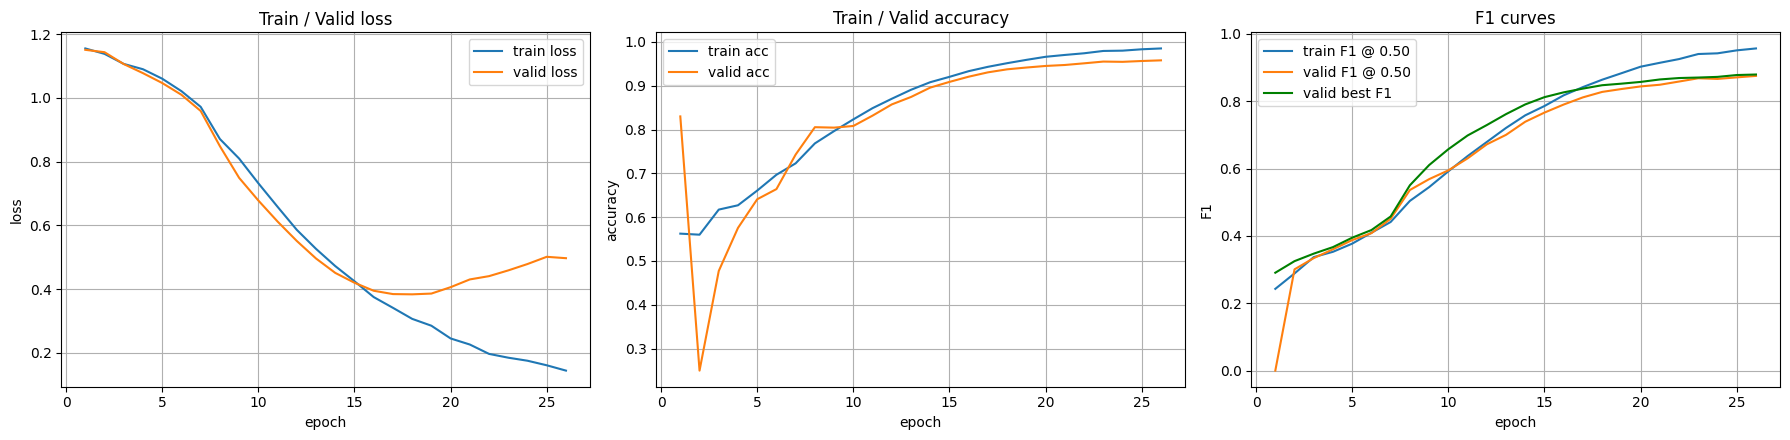

train 027:   0%|          | 0/1250 [00:00<?, ?it/s]

In [ ]:
# Stage A: real-only pseudo-CFA warmup on IR-CFA train only.
# core_val ids are excluded, so CFA pretrain cannot leak into validation.
if CFG.pretrain_cfa_epochs > 0:
    cfa_real_loader = build_cfa_pretrain_loader(
        data["train_df"],
        train_img_dir=TRAIN_IMG_DIR,
        train_index=data["train_index"],
        batch_size=CFG.batch_size,
    )

    pretrain_cfa_real_only(
        model=model,
        real_loader=cfa_real_loader,
        epochs=CFG.pretrain_cfa_epochs,
        device=DEVICE,
        lr=CFG.pretrain_cfa_lr,
        weight_decay=CFG.pretrain_cfa_weight_decay,
        amp=CFA_PRETRAIN_AMP_ENABLED,
    )

    cfa_diag = cfa_reconstruction_diagnostic(
        model=model,
        loader=val_loader,
        device=DEVICE,
        max_batches=30,
    )
else:
    cfa_diag = None

# Freeze CFA predictor after warmup to keep it as a stable forensic feature extractor.
# If diagnostic is weak, you can manually set CFG.freeze_cfa_after_pretrain=False and rerun.
freeze_cfa = bool(CFG.freeze_cfa_after_pretrain and CFG.pretrain_cfa_epochs > 0)
set_cfa_trainable(model, trainable=not freeze_cfa)

print("CFA predictor trainable during Stage B:", not freeze_cfa)
print("Trainable params for classifier training:", count_parameters(model, trainable_only=True))

criterion = create_criterion(data["train_df"])

optimizer = create_optimizer(
    model,
    lr=CFG.lr,
    weight_decay=CFG.weight_decay,
)

num_training_steps = CFG.epochs * len(train_loader)
num_warmup_steps = CFG.warmup_epochs * len(train_loader)

scheduler = create_scheduler(
    optimizer,
    num_training_steps=num_training_steps,
    num_warmup_steps=num_warmup_steps,
)

extra_info = {
    "train_id_has_ext": data["train_id_has_ext"],
    "original_id_col": data["original_id_col"],
    "original_target_col": data["original_target_col"],
    "n_pos": data["n_pos"],
    "n_neg": data["n_neg"],
    "val_n_pos": data["val_n_pos"],
    "val_n_neg": data["val_n_neg"],
    "split_source": data["split_source"],
    "external_val_cache_path": data["external_val_cache_path"],
    "core_val_expected_n": CFG.external_val_expected_n,
    "core_val_actual_n": len(data["core_val_ids"]) if data["core_val_ids"] is not None else None,
    "cfa_diag": cfa_diag,
}

history_df, best_ckpt_path = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=CFG.epochs,
    device=DEVICE,
    amp=AMP_ENABLED,
    save_dir=SAVE_DIR,
    extra_checkpoint_info=extra_info,
)

print("Best F1 checkpoint path:", best_ckpt_path)
print("Min valid loss checkpoint path:", BEST_LOSS_CKPT_PATH)


# ============================================================


In [ ]:
# ============================================================
# CELL 8: inference + TTA + submission + honest val/test caches
# ============================================================

def load_ir_cfa_ccnet_checkpoint(checkpoint_path=BEST_F1_CKPT_PATH, device=DEVICE):
    # PyTorch 2.6 safe loading: weights_only=False is required because checkpoint stores dict metadata.
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

    arch_config = ckpt.get("arch_config", {})
    model = IRCFACCNet(**arch_config).to(device)

    state = ckpt.get("model_state", ckpt)
    model.load_state_dict(state, strict=True)
    model.eval()

    print(f"Loaded checkpoint: {checkpoint_path}")
    print(f"  epoch: {ckpt.get('epoch', 'NA')}")
    print(f"  monitor: {ckpt.get('monitor_name', 'NA')}")
    print(f"  best_metric: {ckpt.get('best_metric', 'NA')}")
    print(f"  best_threshold: {ckpt.get('best_threshold', CFG.fixed_threshold)}")

    return model, ckpt


@torch.no_grad()
def predict_loader_logits(model, loader, device=DEVICE, amp=AMP_ENABLED, desc="predict"):
    model.eval()
    ids = []
    logits_all = []

    pbar = tqdm(loader, total=len(loader), desc=desc, leave=CFG.progress_bar_leave)
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        with autocast(enabled=amp):
            output = model(images)
            logits = get_logits_from_output(output)
        logits = safe_nan_to_num(logits.float(), clip=CFG.logit_tanh_scale)
        ids.extend(batch["id"])
        logits_all.append(logits.detach().float().cpu().numpy())

    logits_all = np.concatenate(logits_all)
    return ids, logits_all


@torch.no_grad()
def predict_df_logits_tta(
    model,
    df,
    img_dir,
    has_labels=False,
    image_index=None,
    tta_modes=CFG.tta_modes,
    batch_size=None,
    device=DEVICE,
    amp=AMP_ENABLED,
    desc_prefix="predict",
):
    ids_ref = None
    logits_sum = None

    for mode in tta_modes:
        ds = ImageBinaryDataset(
            df,
            img_dir=img_dir,
            transform=get_valid_transform(mode),
            has_labels=has_labels,
            image_index=image_index,
        )
        loader = build_dataloader(
            ds,
            batch_size=batch_size or CFG.batch_size * 2,
            shuffle=False,
            drop_last=False,
        )
        ids, logits = predict_loader_logits(
            model,
            loader,
            device=device,
            amp=amp,
            desc=f"{desc_prefix} {mode}",
        )

        if ids_ref is None:
            ids_ref = ids
            logits_sum = logits.astype(np.float64)
        else:
            assert ids == ids_ref, "TTA id order mismatch"
            logits_sum += logits.astype(np.float64)

    logits_avg = logits_sum / float(len(tta_modes))
    probs = sigmoid_np(logits_avg)
    return ids_ref, logits_avg, probs


def save_prediction_csv(ids, logits, out_path, labels=None, threshold=None, include_predicted_class=False):
    probs = sigmoid_np(logits)
    out = pd.DataFrame({
        "id": ids,
        "prob": probs.astype(float),
        "probability": probs.astype(float),
        "logit": np.asarray(logits, dtype=float),
    })
    if labels is not None:
        out["target"] = np.asarray(labels).astype(int)
    if include_predicted_class:
        if threshold is None:
            threshold = CFG.fixed_threshold
        out["predicted_class"] = (out["prob"].values >= float(threshold)).astype(int)
    out.to_csv(out_path, index=False)
    print(f"Saved predictions: {out_path} | n={len(out)}")
    return out


def save_val_predictions_for_checkpoint(
    checkpoint_path,
    val_df,
    out_path,
    cache_path=None,
    device=DEVICE,
    tta_modes=CFG.tta_modes,
):
    model, ckpt = load_ir_cfa_ccnet_checkpoint(checkpoint_path, device=device)
    ids, logits, probs = predict_df_logits_tta(
        model=model,
        df=val_df,
        img_dir=TRAIN_IMG_DIR,
        has_labels=True,
        image_index=None,
        tta_modes=tta_modes,
        batch_size=CFG.batch_size * 2,
        device=device,
        amp=AMP_ENABLED,
        desc_prefix="val TTA",
    )

    labels = val_df["target"].astype(int).values
    best_threshold = float(ckpt.get("best_threshold", CFG.fixed_threshold))
    pred_df = save_prediction_csv(
        ids,
        logits,
        out_path,
        labels=labels,
        threshold=best_threshold,
        include_predicted_class=True,
    )
    if cache_path is not None:
        cache_df = pred_df[["id", "prob", "logit"]].copy()
        cache_df.to_csv(cache_path, index=False)
        print(f"Saved ensemble cache: {cache_path} | n={len(cache_df)}")

    return pred_df, ckpt


def save_test_predictions_for_checkpoint(
    checkpoint_path,
    test_df,
    detailed_out_path,
    cache_path=None,
    submission_path=None,
    device=DEVICE,
    tta_modes=CFG.tta_modes,
):
    model, ckpt = load_ir_cfa_ccnet_checkpoint(checkpoint_path, device=device)
    ids, logits, probs = predict_df_logits_tta(
        model=model,
        df=test_df,
        img_dir=TEST_IMG_DIR,
        has_labels=False,
        image_index=None,
        tta_modes=tta_modes,
        batch_size=CFG.batch_size * 2,
        device=device,
        amp=AMP_ENABLED,
        desc_prefix="test TTA",
    )

    best_threshold = float(ckpt.get("best_threshold", CFG.fixed_threshold))
    pred_df = save_prediction_csv(
        ids,
        logits,
        detailed_out_path,
        labels=None,
        threshold=best_threshold,
        include_predicted_class=True,
    )

    if cache_path is not None:
        cache_df = pred_df[["id", "prob", "logit"]].copy()
        cache_df.to_csv(cache_path, index=False)
        print(f"Saved ensemble cache: {cache_path} | n={len(cache_df)}")

    if submission_path is not None:
        submission = pd.DataFrame({
            "id": pred_df["id"].values,
            "target_feature": pred_df["predicted_class"].astype(int).values,
        })
        submission.to_csv(submission_path, index=False)
        print(f"Saved submission: {submission_path}")

    return pred_df, ckpt


# ---------
# Generate honest validation predictions on exactly core_val ids.
# This overwrites the old leaky IR-CFA cache path with non-leaky predictions.
# ---------
assert "data" in globals(), "Run CELL 7 first so data['val_df'] is the external core-val split."
assert_no_leakage_against_core_val(
    data["train_df"],
    data["val_df"],
    data["core_val_ids"],
    expected_n=CFG.external_val_expected_n,
)

val_pred_df, val_ckpt = save_val_predictions_for_checkpoint(
    checkpoint_path=BEST_F1_CKPT_PATH,
    val_df=data["val_df"],
    out_path=VAL_PRED_CSV_BEST_F1,
    cache_path=CFG.ir_cfa_val_cache_path,
    device=DEVICE,
    tta_modes=CFG.tta_modes,
)

# Hard assert: saved IR-CFA val ids equal external core_val ids.
saved_val_keys = set(canonical_id(x) for x in val_pred_df["id"].values)
core_val_keys = set(canonical_id(x) for x in data["core_val_ids"])
assert saved_val_keys == core_val_keys, "Saved IR-CFA val predictions do not match core_val ids."
print("Honest IR-CFA val predictions match core_val ids exactly.")

# Also save min-valid-loss val predictions for calibration experiments.
if os.path.exists(BEST_LOSS_CKPT_PATH):
    save_val_predictions_for_checkpoint(
        checkpoint_path=BEST_LOSS_CKPT_PATH,
        val_df=data["val_df"],
        out_path=VAL_PRED_CSV_MIN_LOSS,
        cache_path=os.path.join(CACHE_DIR, "default_val_ir_cfa_ccnet_minloss_probs_logits.csv"),
        device=DEVICE,
        tta_modes=CFG.tta_modes,
    )

# ---------
# Test predictions and submission from best-F1 checkpoint.
# ---------
test_df = data.get("test_df", None)
if test_df is None:
    test_df = build_test_dataframe(TEST_IMG_DIR, train_id_has_ext=data.get("train_id_has_ext", False))

submission_path = os.path.join(SAVE_DIR, "submission.csv")

test_pred_df, test_ckpt = save_test_predictions_for_checkpoint(
    checkpoint_path=BEST_F1_CKPT_PATH,
    test_df=test_df,
    detailed_out_path=TEST_PRED_CSV_BEST_F1,
    cache_path=CFG.ir_cfa_test_cache_path,
    submission_path=submission_path,
    device=DEVICE,
    tta_modes=CFG.tta_modes,
)

# Optional min-valid-loss test predictions for calibrated blending experiments.
if os.path.exists(BEST_LOSS_CKPT_PATH):
    save_test_predictions_for_checkpoint(
        checkpoint_path=BEST_LOSS_CKPT_PATH,
        test_df=test_df,
        detailed_out_path=TEST_PRED_CSV_MIN_LOSS,
        cache_path=os.path.join(CACHE_DIR, "default_test_ir_cfa_ccnet_minloss_probs_logits.csv"),
        submission_path=None,
        device=DEVICE,
        tta_modes=CFG.tta_modes,
    )

print(val_pred_df.head())
print(test_pred_df.head())


# ============================================================


In [ ]:
# ============================================================
# CELL 9: ensemble-ready outputs and no-leakage blend diagnostic
# ============================================================

def probability_dict_from_ids_probs(ids, probs):
    return {canonical_id(i): float(p) for i, p in zip(ids, probs)}


def load_prediction_csv_as_dict(path, value_col="prob"):
    df = pd.read_csv(path)
    if "id" not in df.columns:
        raise ValueError(f"Prediction csv must contain id column: {path}")
    if value_col not in df.columns:
        if value_col == "prob" and "probability" in df.columns:
            value_col = "probability"
        elif value_col == "probability" and "prob" in df.columns:
            value_col = "prob"
        else:
            raise ValueError(f"Column {value_col} not found in {path}. Columns: {df.columns.tolist()}")
    return {canonical_id(i): float(v) for i, v in zip(df["id"].values, df[value_col].values)}


def load_model_if_needed(model_or_checkpoint, device=DEVICE):
    if isinstance(model_or_checkpoint, str):
        model, ckpt = load_ir_cfa_ccnet_checkpoint(model_or_checkpoint, device=device)
        return model, ckpt
    return model_or_checkpoint, None


@torch.no_grad()
def collect_val_probs_ir_cfa(
    model_or_checkpoint=BEST_F1_CKPT_PATH,
    val_df=None,
    cache_path=CFG.ir_cfa_val_cache_path,
    force_recompute=False,
    tta_modes=CFG.tta_modes,
    batch_size=None,
    device=DEVICE,
    amp=AMP_ENABLED,
):
    """
    Returns dict: canonical_id -> probability.
    By default loads the honest non-leaky cache if it exists.
    """
    if (not force_recompute) and cache_path is not None and os.path.exists(cache_path):
        return load_prediction_csv_as_dict(cache_path, value_col="prob")

    if val_df is None:
        if "data" in globals():
            val_df = data["val_df"]
        else:
            raise ValueError("val_df is required when data is not available in globals().")

    model, ckpt = load_model_if_needed(model_or_checkpoint, device=device)
    ids, logits, probs = predict_df_logits_tta(
        model=model,
        df=val_df,
        img_dir=TRAIN_IMG_DIR,
        has_labels=True,
        image_index=None,
        tta_modes=tta_modes,
        batch_size=batch_size or CFG.batch_size * 2,
        device=device,
        amp=amp,
        desc_prefix="collect val IR-CFA",
    )

    if cache_path is not None:
        labels = val_df["target"].astype(int).values if "target" in val_df.columns else None
        save_prediction_csv(ids, logits, cache_path, labels=labels, include_predicted_class=False)

    return probability_dict_from_ids_probs(ids, probs)


@torch.no_grad()
def collect_test_probs_ir_cfa(
    model_or_checkpoint=BEST_F1_CKPT_PATH,
    test_df=None,
    cache_path=CFG.ir_cfa_test_cache_path,
    force_recompute=False,
    train_id_has_ext=False,
    tta_modes=CFG.tta_modes,
    batch_size=None,
    device=DEVICE,
    amp=AMP_ENABLED,
):
    """
    Returns dict: canonical_id -> probability.
    """
    if (not force_recompute) and cache_path is not None and os.path.exists(cache_path):
        return load_prediction_csv_as_dict(cache_path, value_col="prob")

    if test_df is None:
        if "data" in globals() and "test_df" in data:
            test_df = data["test_df"]
        else:
            test_df = build_test_dataframe(TEST_IMG_DIR, train_id_has_ext=train_id_has_ext)

    model, ckpt = load_model_if_needed(model_or_checkpoint, device=device)
    ids, logits, probs = predict_df_logits_tta(
        model=model,
        df=test_df,
        img_dir=TEST_IMG_DIR,
        has_labels=False,
        image_index=None,
        tta_modes=tta_modes,
        batch_size=batch_size or CFG.batch_size * 2,
        device=device,
        amp=amp,
        desc_prefix="collect test IR-CFA",
    )

    if cache_path is not None:
        save_prediction_csv(ids, logits, cache_path, labels=None, include_predicted_class=False)

    return probability_dict_from_ids_probs(ids, probs)


# Backward-compatible aliases if old ensemble code calls these names.
def collect_val_probs_new_model(*args, **kwargs):
    return collect_val_probs_ir_cfa(*args, **kwargs)


def collect_test_probs_new_model(*args, **kwargs):
    return collect_test_probs_ir_cfa(*args, **kwargs)


def _preds_to_dict(preds, prefer_col=None):
    if isinstance(preds, dict):
        return {canonical_id(k): float(v) for k, v in preds.items()}

    if isinstance(preds, str):
        preds = pd.read_csv(preds)

    if isinstance(preds, pd.DataFrame):
        df = preds.copy()
        if "id" not in df.columns:
            raise ValueError("Prediction dataframe must contain column 'id'.")

        candidates = []
        if prefer_col is not None:
            candidates.append(prefer_col)
        candidates += ["prob", "probability", "logit", "target_feature"]

        value_col = None
        for c in candidates:
            if c in df.columns:
                value_col = c
                break
        if value_col is None:
            raise ValueError(f"Could not infer prediction column. Columns: {df.columns.tolist()}")

        return {canonical_id(i): float(v) for i, v in zip(df["id"].values, df[value_col].values)}

    raise TypeError(f"Unsupported preds type: {type(preds)}")


def _labels_to_dict(y_true):
    if isinstance(y_true, dict):
        return {canonical_id(k): int(v) for k, v in y_true.items()}

    if isinstance(y_true, str):
        y_true = pd.read_csv(y_true)

    if isinstance(y_true, pd.DataFrame):
        df = y_true.copy()
        if "id" not in df.columns:
            raise ValueError("Label dataframe must contain column 'id'.")
        if "target" in df.columns:
            target_col = "target"
        elif "target_feature" in df.columns:
            target_col = "target_feature"
        elif "label" in df.columns:
            target_col = "label"
        else:
            raise ValueError(f"Could not infer label column. Columns: {df.columns.tolist()}")
        return {canonical_id(i): int(v) for i, v in zip(df["id"].values, df[target_col].values)}

    raise TypeError(f"Unsupported y_true type: {type(y_true)}")


def prob_to_logit_np(p, eps=1e-6):
    p = np.asarray(p, dtype=np.float64)
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def assert_blend_has_no_ir_cfa_leakage(common_ids, ir_train_df=None, ir_val_df=None, expected_n=None):
    common_set = set(canonical_id(x) for x in common_ids)

    if ir_train_df is not None:
        train_set = set(canonical_id(x) for x in ir_train_df["id"].values)
        inter_train = common_set & train_set
        print(f"Blend leakage check | common ∩ IR-CFA train: {len(inter_train)}")
        assert len(inter_train) == 0, "LEAKAGE: blend common ids overlap IR-CFA train ids."

    if ir_val_df is not None:
        val_set = set(canonical_id(x) for x in ir_val_df["id"].values)
        missing_from_val = common_set - val_set
        print(f"Blend leakage check | common ids in IR-CFA val: {len(common_set) - len(missing_from_val)}/{len(common_set)}")
        assert len(missing_from_val) == 0, "Some blend common ids are not in IR-CFA val split."

    if expected_n is not None:
        assert len(common_set) == int(expected_n), f"Expected {expected_n} common validation ids, got {len(common_set)}."

    return True


def blend_diagnostic(
    core_preds,
    ir_cfa_preds,
    y_true,
    core_is_logit=False,
    ir_is_logit=False,
    core_value_col=None,
    ir_value_col=None,
    alpha_grid=None,
    threshold_grid_values=None,
    zscore_ir=True,
    ir_train_df=None,
    ir_val_df=None,
    expected_n=CFG.external_val_expected_n,
):
    """
    Honest logit blend diagnostic.

    Blend form:
        blend_logit = core_logit + alpha * zscore(ir_cfa_logit)

    Pass ir_train_df=data['train_df'] and ir_val_df=data['val_df'] to enforce no-leakage assertions.
    """
    if alpha_grid is None:
        alpha_grid = np.linspace(-2.0, 2.0, 161)
    if threshold_grid_values is None:
        threshold_grid_values = threshold_grid()

    core_prefer = core_value_col if core_value_col is not None else ("logit" if core_is_logit else "prob")
    ir_prefer = ir_value_col if ir_value_col is not None else ("logit" if ir_is_logit else "prob")

    core_dict = _preds_to_dict(core_preds, prefer_col=core_prefer)
    ir_dict = _preds_to_dict(ir_cfa_preds, prefer_col=ir_prefer)
    y_dict = _labels_to_dict(y_true)

    common_ids = sorted(set(core_dict.keys()) & set(ir_dict.keys()) & set(y_dict.keys()))
    if len(common_ids) == 0:
        raise ValueError("No common ids between core_preds, ir_cfa_preds, and y_true.")

    assert_blend_has_no_ir_cfa_leakage(
        common_ids,
        ir_train_df=ir_train_df,
        ir_val_df=ir_val_df,
        expected_n=expected_n,
    )

    y = np.array([y_dict[i] for i in common_ids], dtype=int)
    core_values = np.array([core_dict[i] for i in common_ids], dtype=np.float64)
    ir_values = np.array([ir_dict[i] for i in common_ids], dtype=np.float64)

    core_logits = core_values if core_is_logit else prob_to_logit_np(core_values)
    ir_logits = ir_values if ir_is_logit else prob_to_logit_np(ir_values)

    if zscore_ir:
        ir_for_blend = (ir_logits - ir_logits.mean()) / (ir_logits.std() + 1e-9)
    else:
        ir_for_blend = ir_logits

    corr = float(np.corrcoef(core_logits, ir_logits)[0, 1]) if len(common_ids) > 2 else np.nan

    rows = []
    best = {"f1": -1.0, "alpha": None, "threshold": None}
    for alpha in alpha_grid:
        blend_logits = core_logits + float(alpha) * ir_for_blend
        blend_probs = sigmoid_np(blend_logits)
        f1, thr = find_best_f1_threshold(y, blend_probs, thresholds=threshold_grid_values)
        rows.append({"alpha": float(alpha), "best_f1": float(f1), "best_threshold": float(thr)})
        if f1 > best["f1"]:
            best = {"f1": float(f1), "alpha": float(alpha), "threshold": float(thr)}

    result_df = pd.DataFrame(rows).sort_values("best_f1", ascending=False).reset_index(drop=True)

    core_base_f1, core_base_thr = find_best_f1_threshold(y, sigmoid_np(core_logits), thresholds=threshold_grid_values)
    ir_base_f1, ir_base_thr = find_best_f1_threshold(y, sigmoid_np(ir_logits), thresholds=threshold_grid_values)

    print("Blend diagnostic")
    print("----------------")
    print(f"Common ids: {len(common_ids)}")
    print(f"Logit correlation core vs IR-CFA: {corr:.6f}")
    print(f"Core best F1:   {core_base_f1:.6f} @thr={core_base_thr:.5f}")
    print(f"IR-CFA best F1: {ir_base_f1:.6f} @thr={ir_base_thr:.5f}")
    print(f"Best blend F1:  {best['f1']:.6f} | alpha={best['alpha']:.5f} | threshold={best['threshold']:.5f}")

    return best, result_df


# Example usage after CELL 8 saved honest IR-CFA val cache:
# core_cache = "/content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_efficientnet_ema_probs_logits.csv"
# ir_cache   = CFG.ir_cfa_val_cache_path
# best_blend, blend_table = blend_diagnostic(
#     core_preds=core_cache,
#     ir_cfa_preds=ir_cache,
#     y_true=data["val_df"],
#     core_is_logit=False,
#     ir_is_logit=False,
#     ir_train_df=data["train_df"],
#     ir_val_df=data["val_df"],
#     expected_n=CFG.external_val_expected_n,
# )
# display(blend_table.head(20))
